In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from allsky.plotting import plot_brightness, plot_exposure, plot_synthetic_luminous_flux

image_location = Path("../../images/NightSkyImages/")
clear_image_location = Path("../../images/SelectedSkyImages/")
enriched_df_location = Path("../../data/enriched_df.parquet")

if (not image_location.exists()) or (not enriched_df_location.exists()):
    raise FileNotFoundError

In [2]:
enriched_df = pd.read_parquet(enriched_df_location)

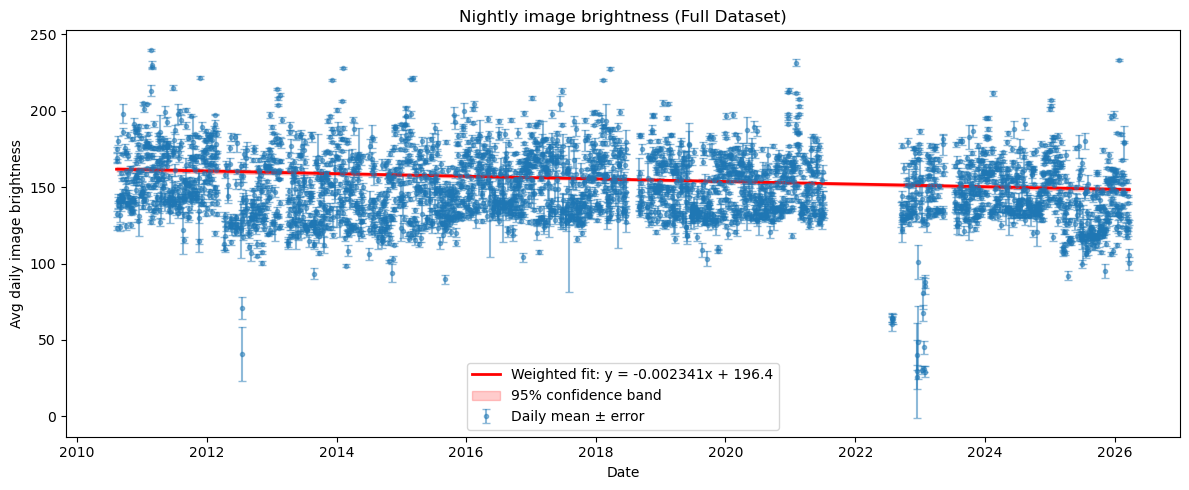

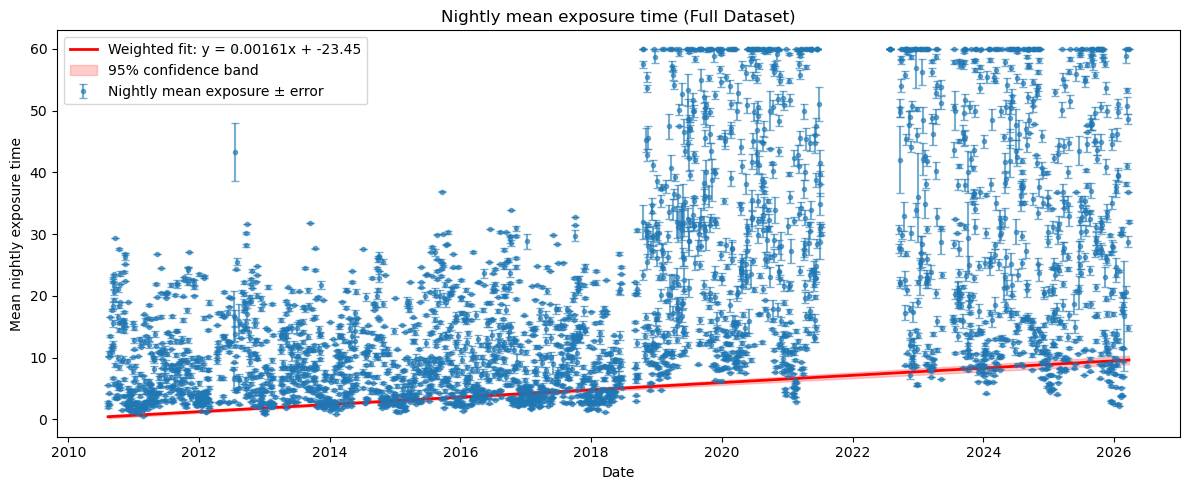

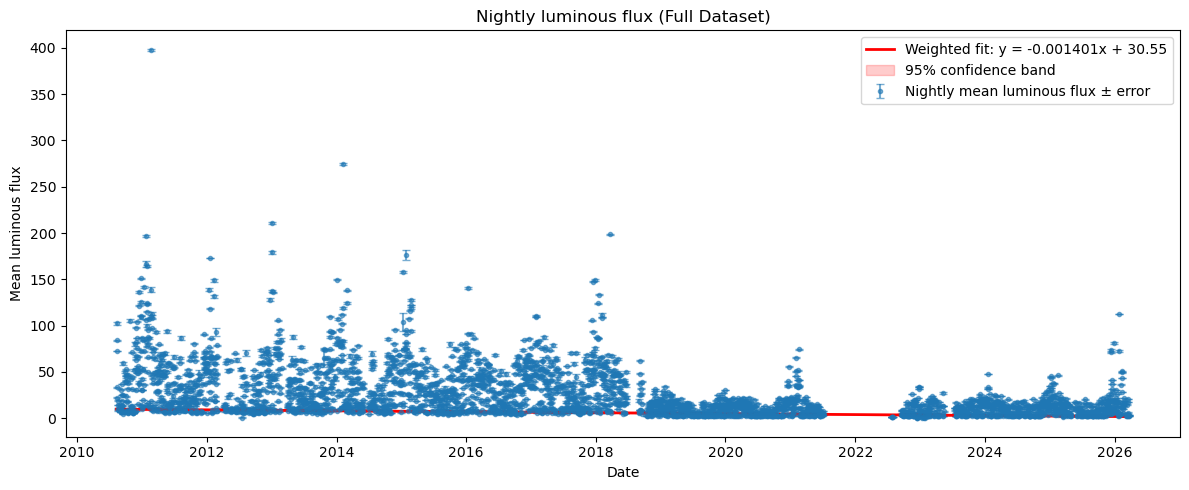

In [3]:
_ = plot_brightness(enriched_df, "Full Dataset")
_ = plot_exposure(enriched_df, "Full Dataset")
_ = plot_synthetic_luminous_flux(enriched_df, "Full Dataset")

In [82]:
recent_df = enriched_df[
        (pd.to_datetime(enriched_df["date"], format="%Y/%m/%d", errors="coerce").dt.year >= 2022)
]

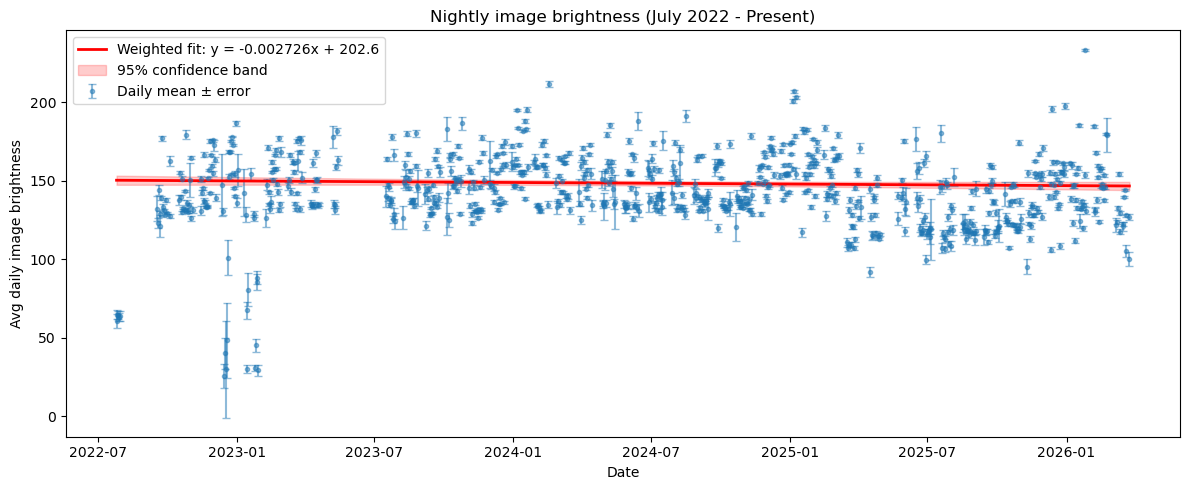

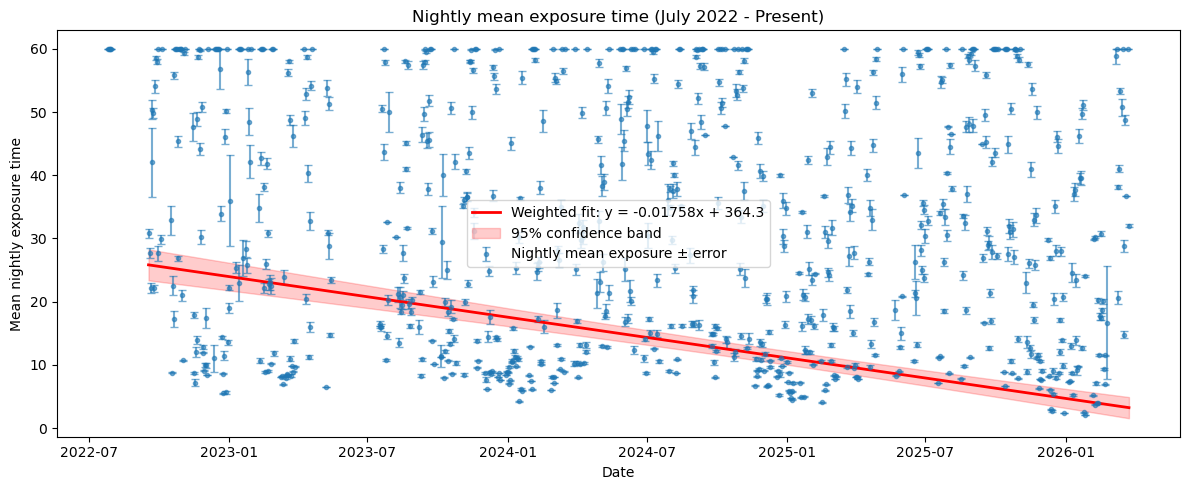

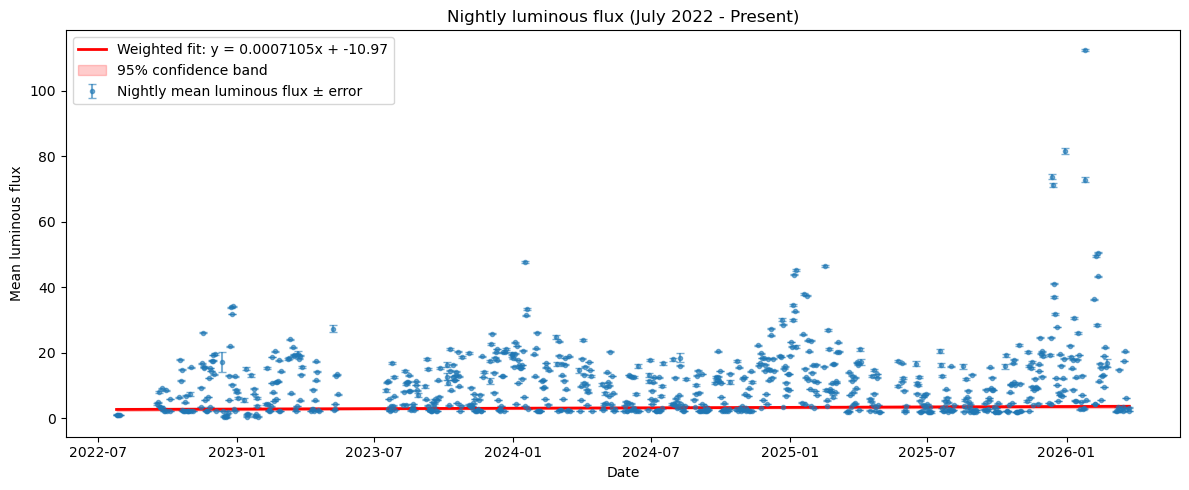

In [83]:
_ = plot_brightness(recent_df, "July 2022 - Present")
_ = plot_exposure(recent_df, "July 2022 - Present")
_ = plot_synthetic_luminous_flux(recent_df, "July 2022 - Present")

In [84]:
enriched_df

,date,time,exposure,filename,source_file,timestamp,image_paths,image_mean,image_sum,image_min,image_max,image_std,image_medians
8,2010/08/11,22:38:00,2.7883,000021274,2010-08.parquet,2010-08-11 22:38:00,../../images/SomeSkyImages/2010-08/AllSkyImage...,157.789822,19822662,105,242,29.416727,156.0
9,2010/08/11,22:39:17,2.4769,000021275,2010-08.parquet,2010-08-11 22:39:17,../../images/SomeSkyImages/2010-08/AllSkyImage...,159.858382,20082529,102,242,25.961395,158.0
10,2010/08/11,22:40:17,2.4769,000021276,2010-08.parquet,2010-08-11 22:40:17,../../images/SomeSkyImages/2010-08/AllSkyImage...,163.385713,20525657,115,240,25.684782,161.0
11,2010/08/11,22:41:34,2.4769,000021277,2010-08.parquet,2010-08-11 22:41:34,../../images/SomeSkyImages/2010-08/AllSkyImage...,166.985608,20977901,117,245,28.818942,163.0
12,2010/08/11,22:42:34,2.4769,000021278,2010-08.parquet,2010-08-11 22:42:34,../../images/SomeSkyImages/2010-08/AllSkyImage...,158.146314,19867447,99,248,34.864647,154.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,2026/03/25,05:40:08,32.0241,000422467,2026-03.parquet,2026-03-25 05:40:08,../../images/SomeSkyImages/2026-03/AllSkyImage...,103.790141,13038844,51,221,19.991641,102.0
5,2026/03/25,05:40:41,32.0241,000422468,2026-03.parquet,2026-03-25 05:40:41,../../images/SomeSkyImages/2026-03/AllSkyImage...,103.978412,13062496,57,235,19.158357,102.0
6,2026/03/25,05:41:34,36.3559,000422469,2026-03.parquet,2026-03-25 05:41:34,../../images/SomeSkyImages/2026-03/AllSkyImage...,107.699698,13529990,56,232,20.021279,105.0
7,2026/03/25,05:42:11,36.3559,000422470,2026-03.parquet,2026-03-25 05:42:11,../../images/SomeSkyImages/2026-03/AllSkyImage...,107.371680,13488782,59,253,21.015155,105.0


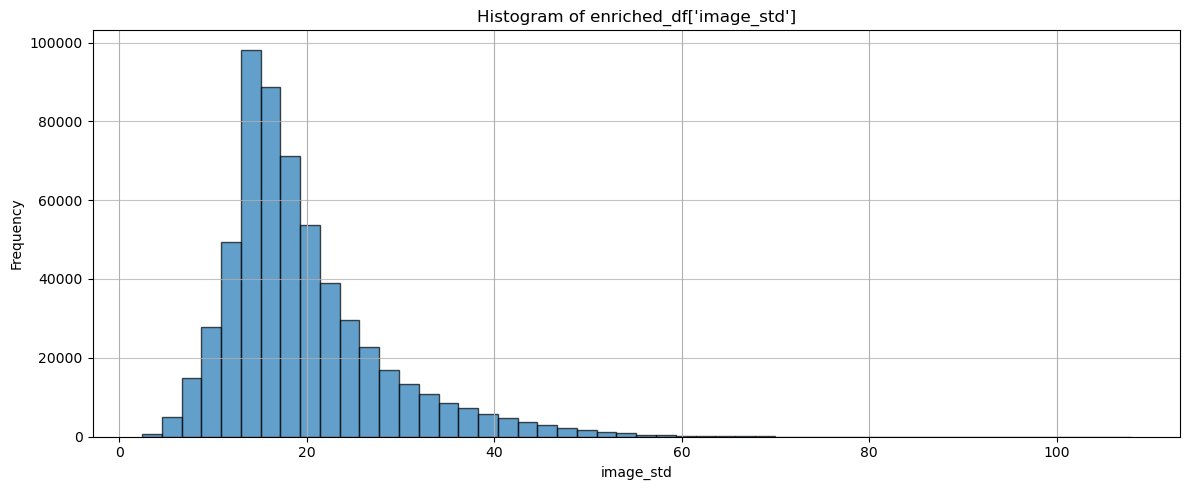

In [85]:
fig, ax = plt.subplots(figsize=(12, 5))
enriched_df['image_std'].hist(ax=ax, bins=50, edgecolor='black', alpha=0.7)
plt.title('Histogram of enriched_df[\'image_std\']')
plt.xlabel('image_std')
plt.ylabel('Frequency')
ax.grid(axis='y', alpha=0.75)
fig.tight_layout()

In [86]:
date_dt = pd.to_datetime(enriched_df["date"], format="%Y/%m/%d", errors="coerce")

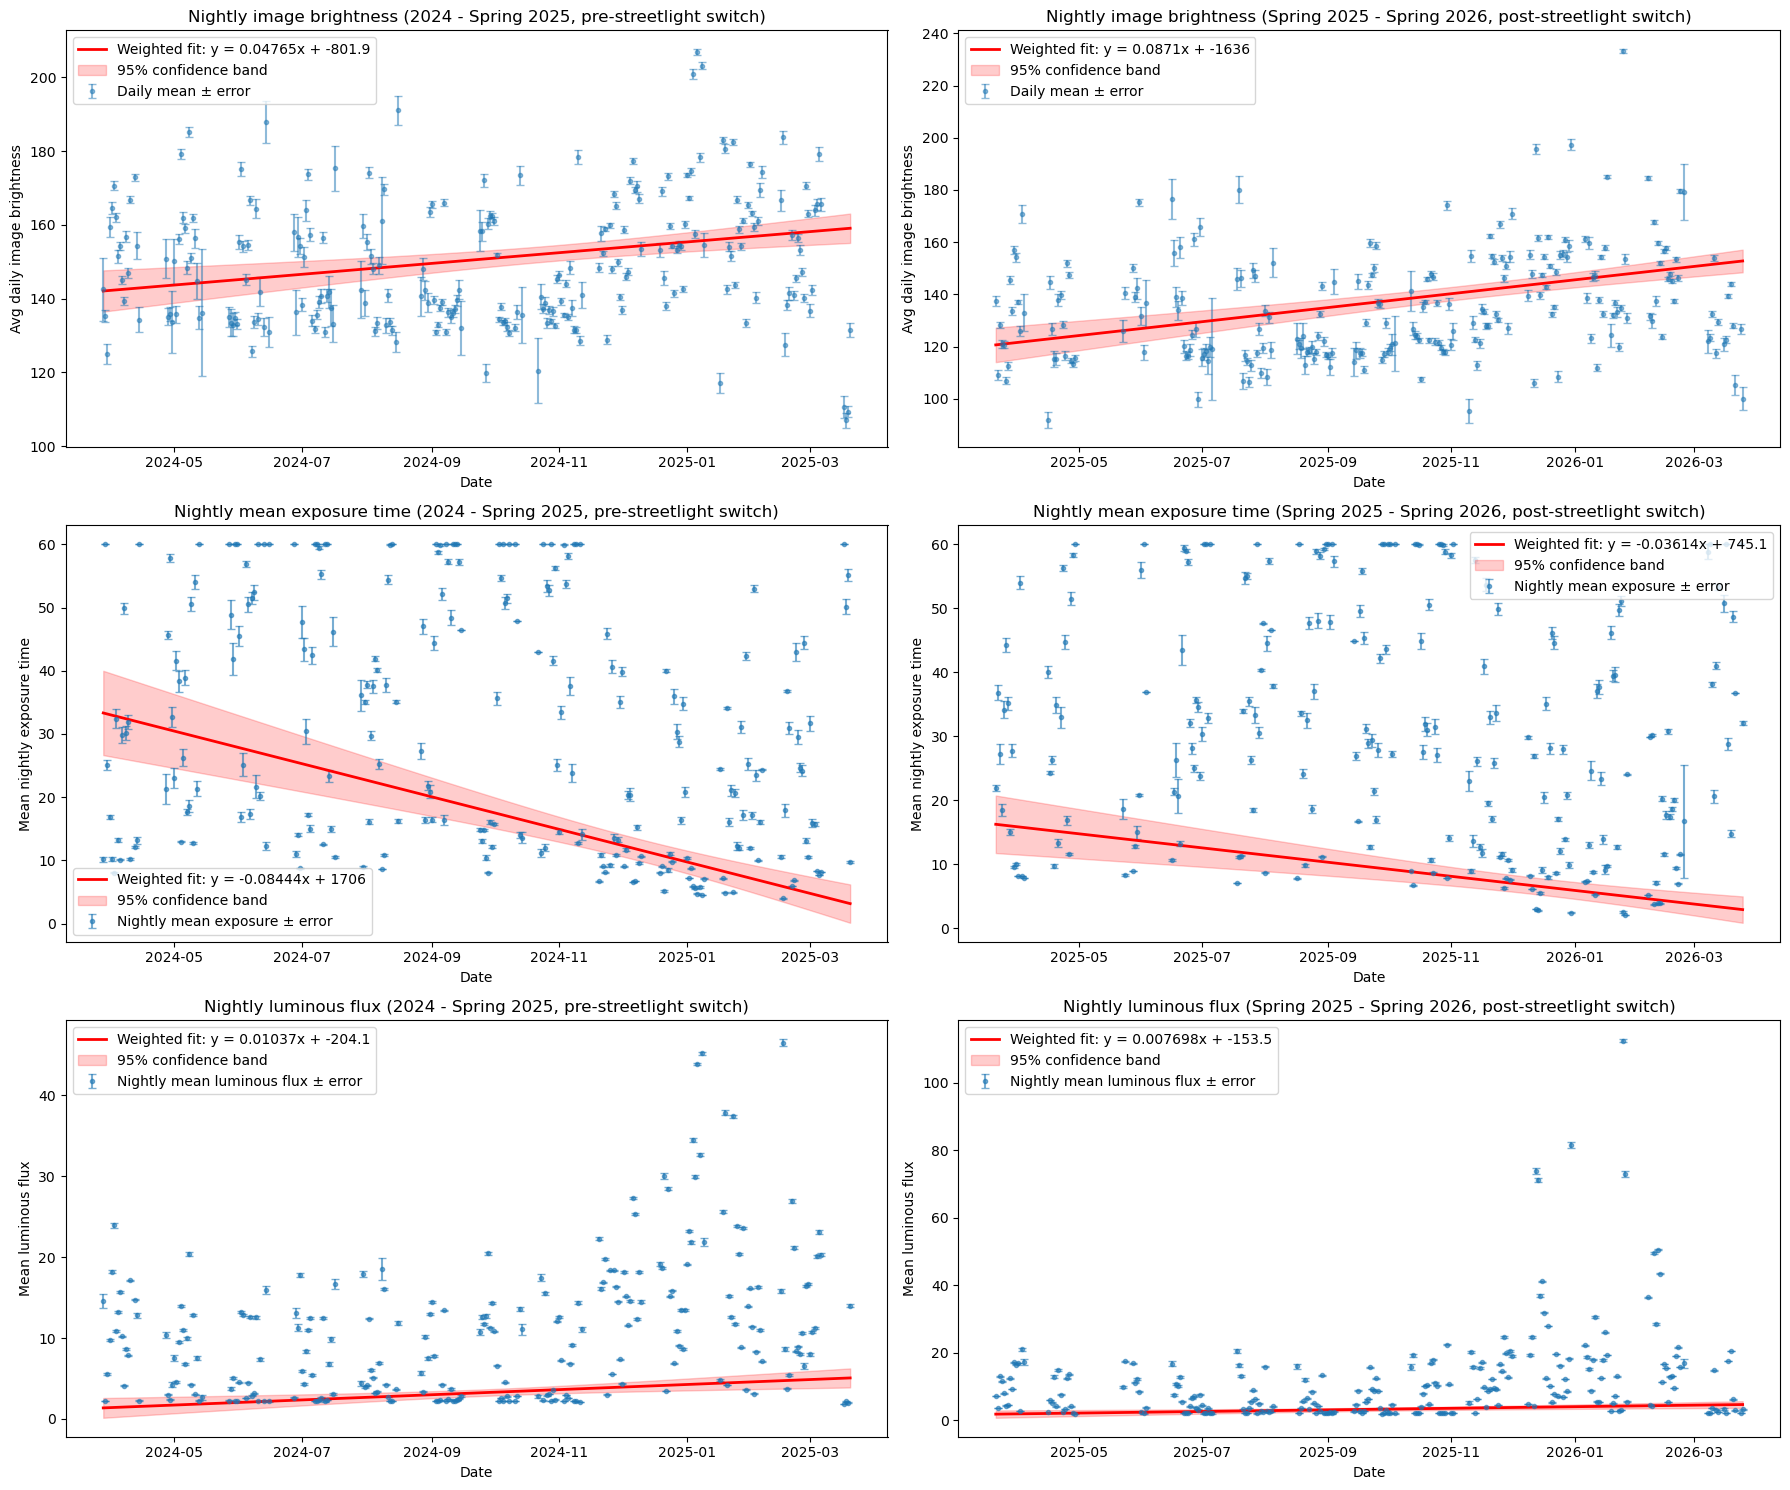

In [87]:
def plot_graph(split_date = "2025-03-21", period="D"):
    global preswitch_df, postswitch_df
    fig, axes = plt.subplots(3, 2, figsize=(18, 15), sharex=False)

    preswitch_df = enriched_df[
        (date_dt >= pd.to_datetime(split_date).replace(2024)) &
        (date_dt < pd.to_datetime(split_date))
    ]
    postswitch_df = enriched_df[
        # (date_dt.dt.year >= 2025)
        (date_dt >= pd.to_datetime(split_date))
    ]

    plot_brightness(preswitch_df, "2024 - Spring 2025, pre-streetlight switch", period, ax=axes[0, 0])
    plot_exposure(preswitch_df, "2024 - Spring 2025, pre-streetlight switch", period, ax=axes[1, 0])
    plot_synthetic_luminous_flux(preswitch_df, "2024 - Spring 2025, pre-streetlight switch", period, ax=axes[2, 0])
    plot_brightness(postswitch_df, "Spring 2025 - Spring 2026, post-streetlight switch", period, ax=axes[0, 1])
    plot_exposure(postswitch_df, "Spring 2025 - Spring 2026, post-streetlight switch", period, ax=axes[1, 1])
    _ = plot_synthetic_luminous_flux(postswitch_df, "Spring 2025 - Spring 2026, post-streetlight switch", period,
                                     ax=axes[2, 1])
    plt.tight_layout()

plot_graph(period="D")

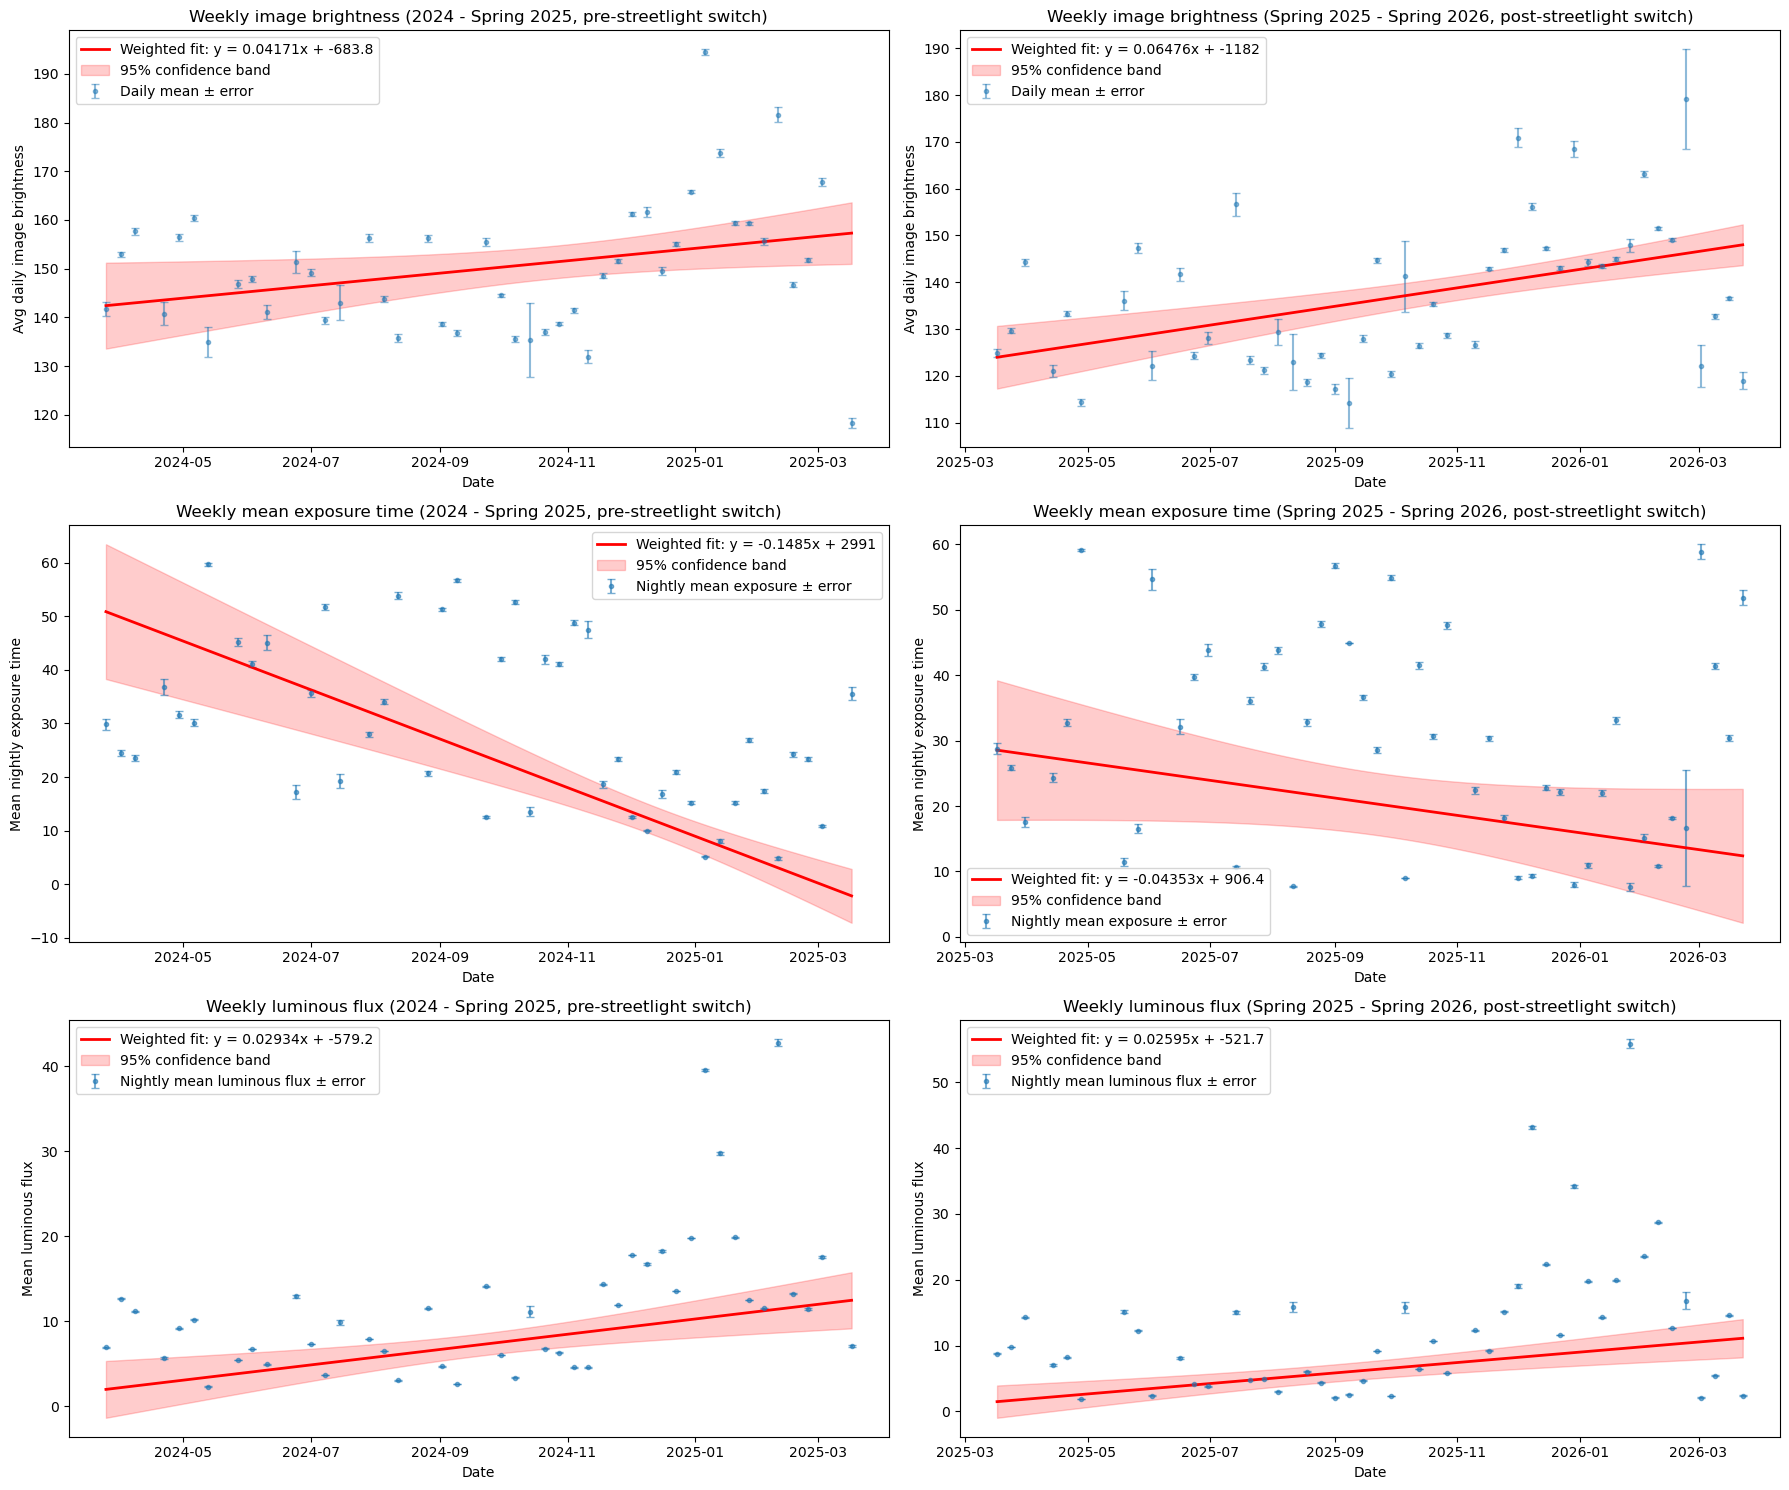

In [88]:
plot_graph(period="W")

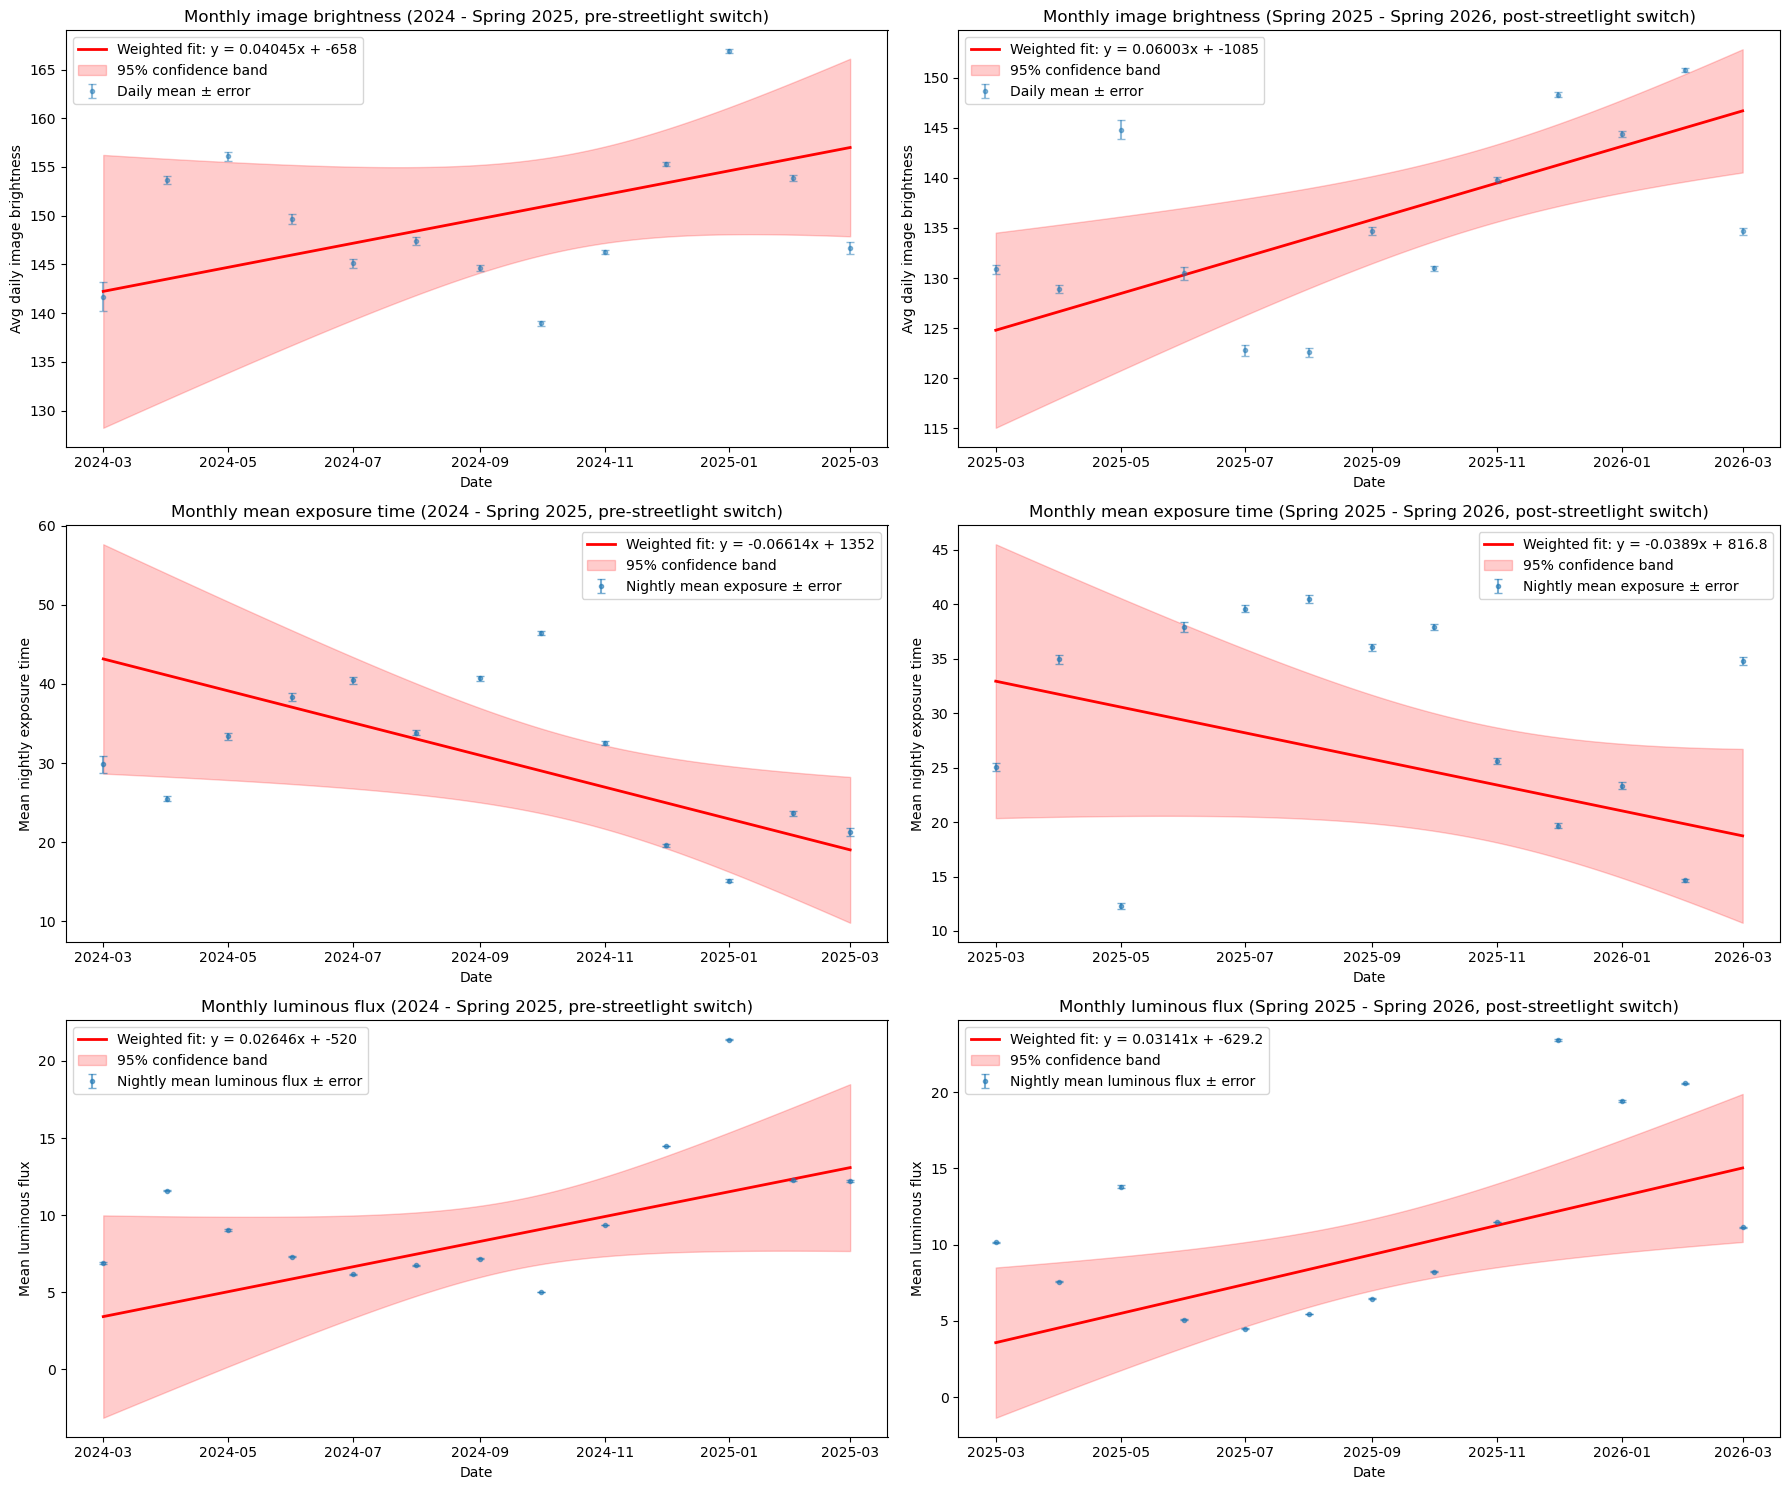

In [89]:
plot_graph(period="M")

In [90]:
len(preswitch_df), len(postswitch_df), len(preswitch_df) + len(postswitch_df)

(53626, 59151, 112777)

---

In [91]:
record_set = set([
    str(clear_image_location.joinpath(f"{source_file[:-8]}/AllSkyImage{filename}.JPG"))
    for filename, source_file in enriched_df[["filename", 'source_file']].to_numpy()
])
image_set = set(list([str(x) for x in clear_image_location.glob("20*-*/*.JPG")]))

In [92]:
record_set.pop(), image_set.pop()

('../../images/SelectedSkyImages/2013-10/AllSkyImage000544800.JPG',
 '../../images/SelectedSkyImages/2024-04/AllSkyImage002185670.JPG')

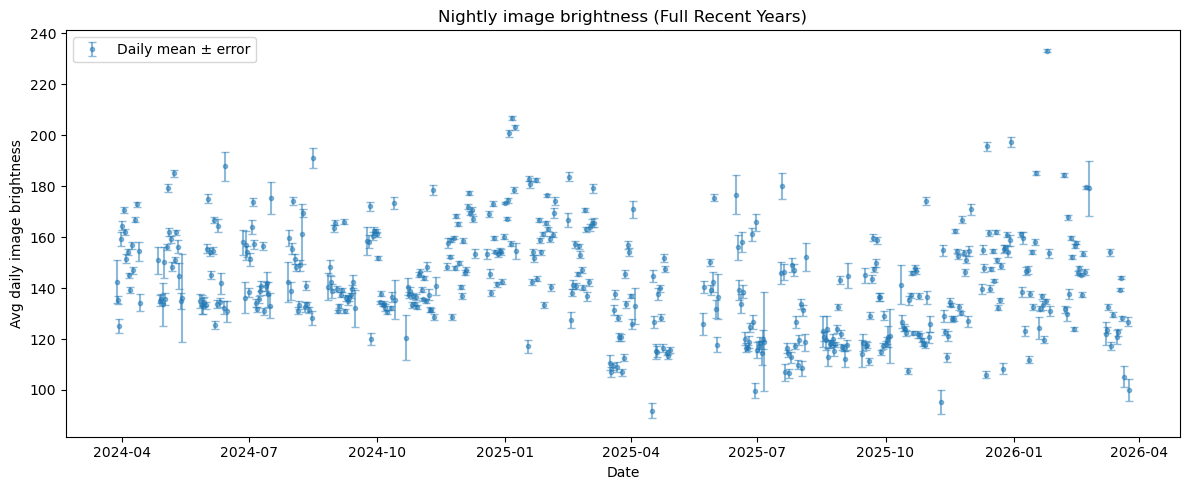

In [93]:
recent_years_df = enriched_df[
    (date_dt >= pd.to_datetime("2024-03-21"))
]
_ = plot_brightness(recent_years_df, "Full Recent Years", plot_best_fit=False)

In [94]:
recent_years_df["image_paths"].str.replace(
    str(image_location), str(clear_image_location)
)

condition = recent_years_df["image_paths"].str.replace(
    str(image_location), str(clear_image_location)
).isin(image_set)


(112777, 24910)

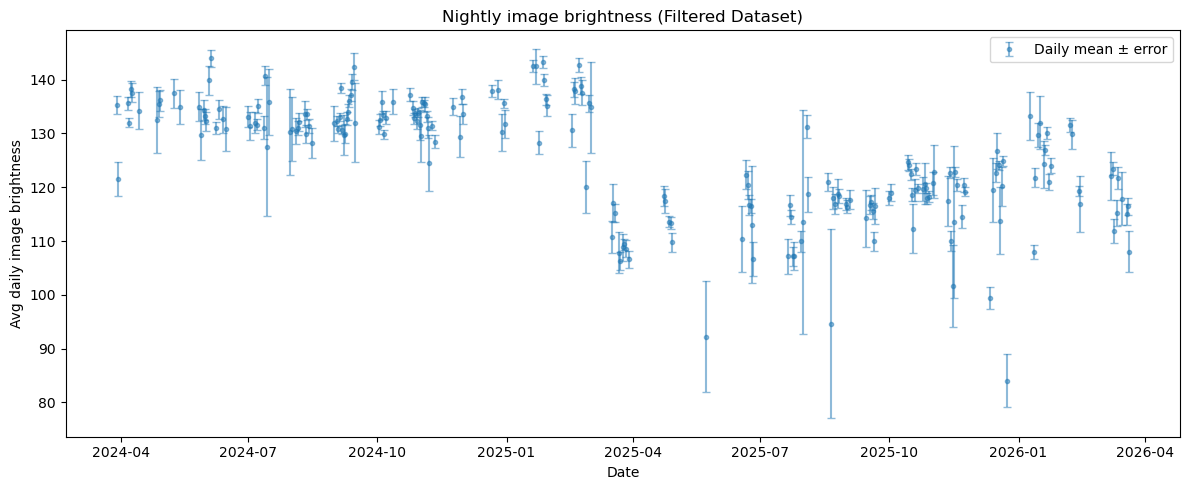

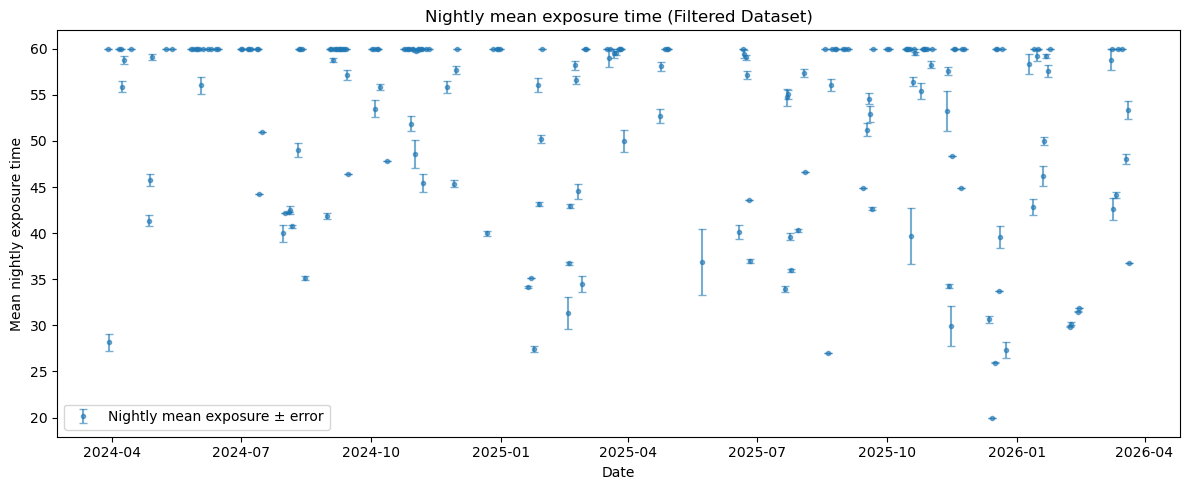

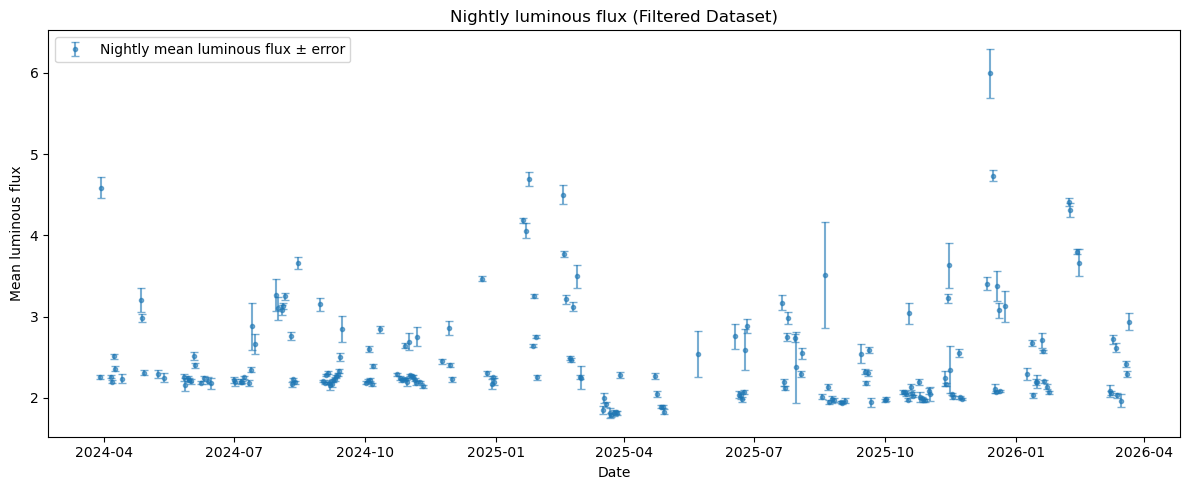

In [95]:
only_clear_nights_df = recent_years_df[condition]
# only_clear_nights_df = only_clear_nights_df[only_clear_nights_df["exposure"] > 50]

plot_line_of_fit = False

_ = plot_brightness(only_clear_nights_df, "Filtered Dataset", plot_best_fit=plot_line_of_fit)
_ = plot_exposure(only_clear_nights_df, "Filtered Dataset", plot_best_fit=plot_line_of_fit)
_ = plot_synthetic_luminous_flux(only_clear_nights_df, "Filtered Dataset", plot_best_fit=plot_line_of_fit)
len(recent_years_df), len(recent_years_df[condition])

In [96]:
before_camera_wonk = only_clear_nights_df[
    (only_clear_nights_df["date"] >= "2025/01/01") &
    (only_clear_nights_df["date"] < "2025/03/04")
]

after_camera_back = only_clear_nights_df[
    (only_clear_nights_df["date"] >= "2025/06/21") &
    (only_clear_nights_df["date"] < "2025/08/20")
]

(
    len(before_camera_wonk), len(after_camera_back),
    before_camera_wonk["image_mean"].mean(),
    before_camera_wonk["image_mean"].std(),
    after_camera_back["image_mean"].mean(),
    after_camera_back["image_mean"].std()
)

(1350,
 1549,
 np.float64(138.63556451211096),
 np.float64(5.361199908805324),
 np.float64(115.06698532889817),
 np.float64(6.711407269585075))

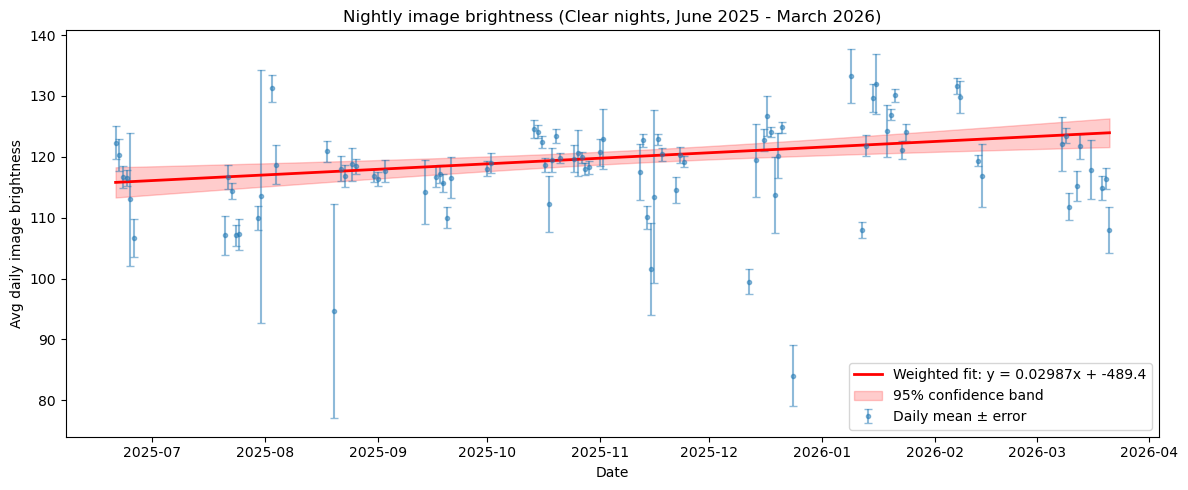

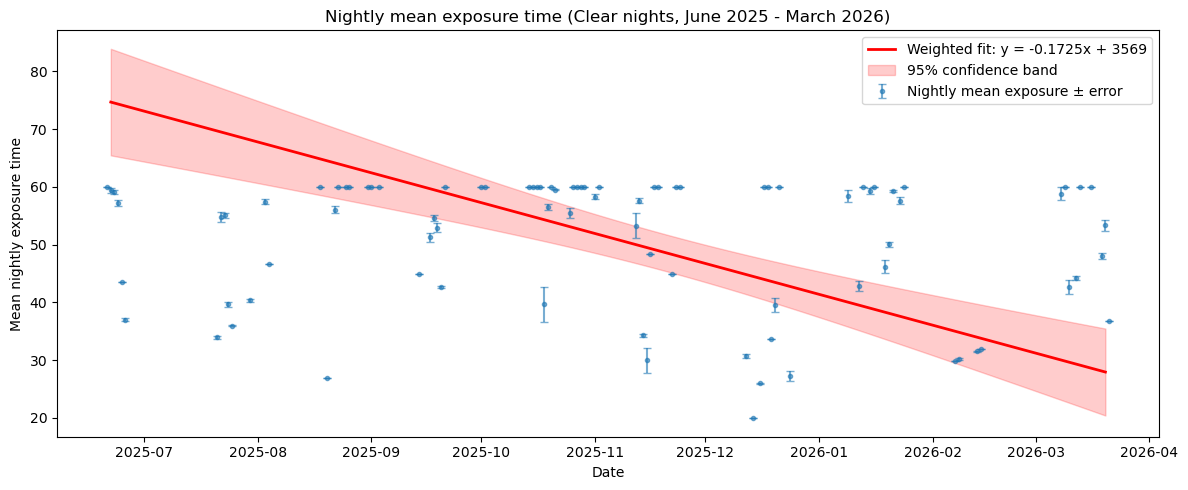

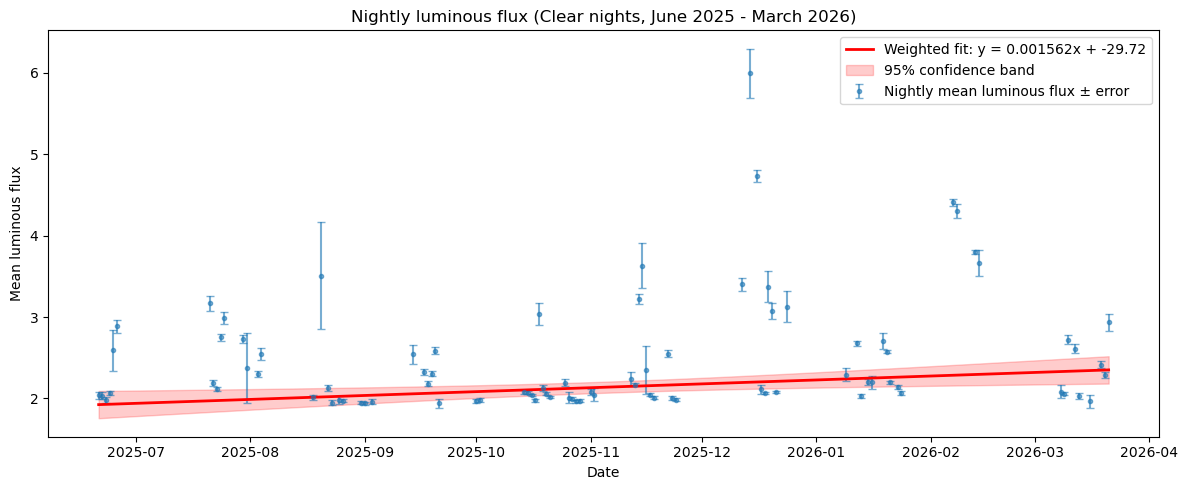

In [97]:
all_after_camera_back = only_clear_nights_df[
    (only_clear_nights_df["date"] >= "2025/06/21")
]

plot_line_of_fit = True

_ = plot_brightness(all_after_camera_back, "Clear nights, June 2025 - March 2026", plot_best_fit=plot_line_of_fit, period="D")
_ = plot_exposure(all_after_camera_back, "Clear nights, June 2025 - March 2026", plot_best_fit=plot_line_of_fit, period="D")
_ = plot_synthetic_luminous_flux(all_after_camera_back, "Clear nights, June 2025 - March 2026", period="D",
                                 plot_best_fit=plot_line_of_fit)

In [98]:
def line_values_and_percent_change(m, b, x_start, x_end):
    start_y = m * x_start + b
    end_y = m * x_end + b
    percent_change = ((end_y - start_y) / start_y) * 100
    return start_y, end_y, percent_change

x_start = mdates.date2num(pd.to_datetime("2025-06-21"))
x_end = mdates.date2num(pd.to_datetime("2026-03-28"))

brightness_m = 0.02987
brightness_b = -489.4

lumflux_m = 0.001562
lumflux_b = -29.72

(
    line_values_and_percent_change(brightness_m, brightness_b, x_start, x_end),
    line_values_and_percent_change(lumflux_m, lumflux_b, x_start, x_end),
)

((np.float64(115.76620000000003),
  np.float64(124.12980000000005),
  np.float64(7.224561227715877)),
 (np.float64(1.926120000000001),
  np.float64(2.3634800000000027),
  np.float64(22.70678877743866)))